In [3]:
import pandas as pd
df = pd.read_csv("data/ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset

df = pd.read_csv("data/ds_salaries.csv")

# 1.drop useless colum
df = df.drop(columns=["Unnamed: 0"])

# 2. Clean experience level column
exp_map = {
    "EN" : "Entry",
    "MI" : "Mid",
    "SE" : "Senior",
    "EX" : "Executive",
}

df["experience_level"] = df["experience_level"].map(exp_map)

#cleaning employment type

emp_map = {
   "FT": "Full-Time",
    "PT": "Part-Time",
    "CT": "Contract",
    "FL": "Freelance" 
}

df["employment_type"] = df["employment_type"].map(emp_map)

#preview cleaned data

print(df.head())

#Check unique values

print("\nExperience Levels:", df["experience_level"].unique())
print("Employment Types:", df["employment_type"].unique())



print("\nAverage Salary by Job Title:::::::::::::::::::::")
# Average salary by job title
salary_by_role = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False)

print("\nTop Paying Roles:")
print(salary_by_role.head(10))

salary_by_location = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False)

print("\nTop Paying Locations:")
print(salary_by_location.head(10))

   work_year experience_level employment_type                   job_title  \
0       2020              Mid       Full-Time              Data Scientist   
1       2020           Senior       Full-Time  Machine Learning Scientist   
2       2020           Senior       Full-Time           Big Data Engineer   
3       2020              Mid       Full-Time        Product Data Analyst   
4       2020           Senior       Full-Time   Machine Learning Engineer   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   70000             EUR          79833                 DE             0   
1  260000             USD         260000                 JP             0   
2   85000             GBP         109024                 GB            50   
3   20000             USD          20000                 HN             0   
4  150000             USD         150000                 US            50   

  company_location company_size  
0               DE            L  
1     

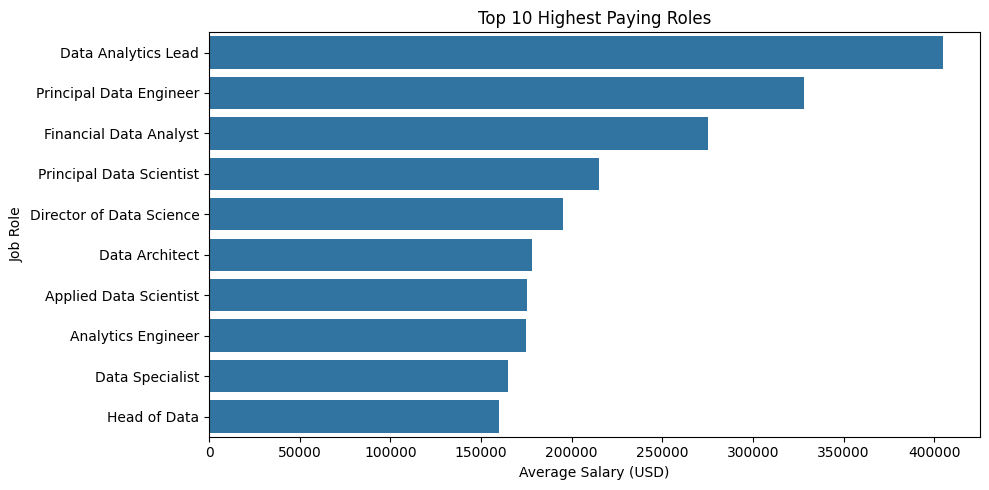

In [9]:
# Top 10 roles
top_roles = salary_by_role.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_roles.values, y=top_roles.index)

plt.title("Top 10 Highest Paying Roles")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Role")

plt.tight_layout()
plt.savefig("charts/top_roles.png")
plt.show()

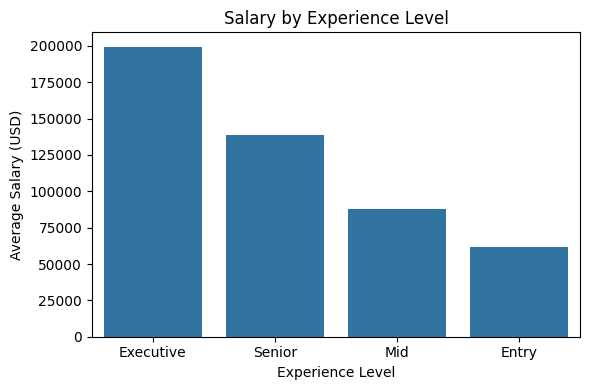

In [11]:
salary_by_exp = df.groupby("experience_level")["salary_in_usd"].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=salary_by_exp.index, y=salary_by_exp.values)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

plt.tight_layout()
plt.savefig("charts/texp_level.png")
plt.show()


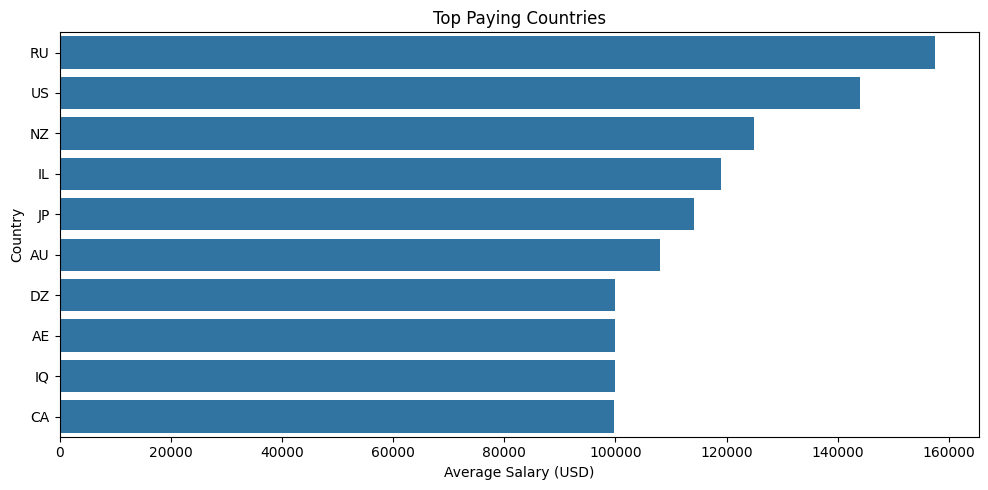

In [10]:
salary_by_country = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False)
top_countries = salary_by_country.head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Paying Countries")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("charts/countries.png")
plt.show()
